In [6]:
from tensorboard.backend.event_processing import event_accumulator

log_dir = r"D:/Btech/Btech-4/Sem-8/BiometricTemplateGeneration/artifacts/plots/tensorboard/casia_Quantized_20260322-143401"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

In [7]:
print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['Loss/Total_Train', 'Loss/ArcFace_Train', 'Loss/Entropy_Train', 'Loss/Total_Val', 'Accuracy/Train', 'Accuracy/Val', 'Metrics/Validation_BER', 'Hyperparameters/Lambda_Entropy', 'LearningRate'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [8]:
scalars = ea.Scalars('Loss/ArcFace_Train')  # change tag accordingly

steps = [s.step for s in scalars]
values = [s.value for s in scalars]

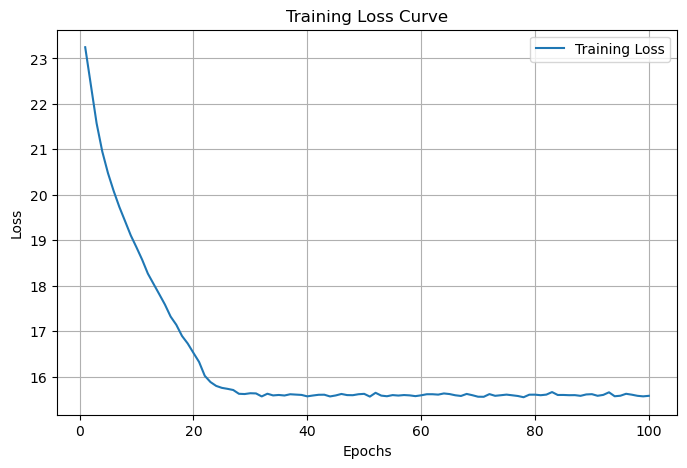

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(steps, values, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)

plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
plt.savefig("loss_curve.pdf")  # vector format for LaTeX

CASIA tags: ['Loss/Total_Train', 'Loss/ArcFace_Train', 'Loss/Entropy_Train', 'Loss/Total_Val', 'Accuracy/Train', 'Accuracy/Val', 'Metrics/Validation_BER', 'Hyperparameters/Lambda_Entropy', 'LearningRate']
FVC2000 tags: ['Loss/Total_Train', 'Loss/ArcFace_Train', 'Loss/Entropy_Train', 'Loss/Total_Val', 'Accuracy/Train', 'Accuracy/Val', 'Metrics/Validation_BER', 'Hyperparameters/Lambda_Entropy', 'LearningRate']
FVC2004 tags: ['Loss/Total_Train', 'Loss/ArcFace_Train', 'Loss/Entropy_Train', 'Loss/Total_Val', 'Accuracy/Train', 'Accuracy/Val', 'Metrics/Validation_BER', 'Hyperparameters/Lambda_Entropy', 'LearningRate']


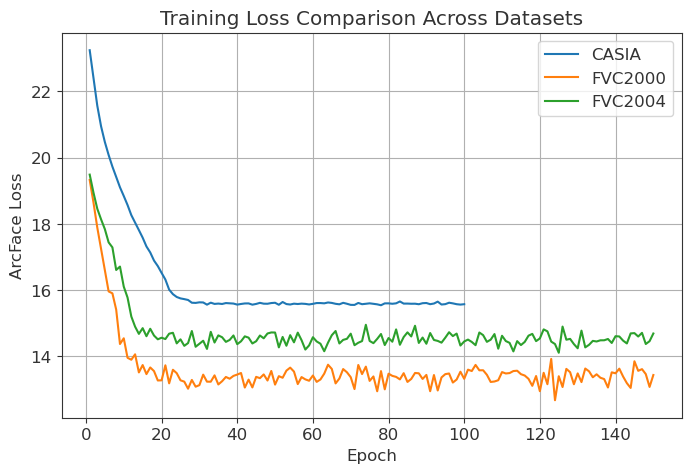

In [3]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import os



runs = {
    "CASIA": "casia_Quantized_20260322-143401",
    "FVC2000": "fvc2000_Quantized_20260322-220217",
    "FVC2004": "fvc2004_Quantized_20260322-230045"
}

tag = "Loss/ArcFace_Train"
base_dir = r"D:/Btech/Btech-4/Sem-8/BiometricTemplateGeneration/artifacts/plots/tensorboard"
plt.figure(figsize=(8,5))

for name, folder in runs.items():
    log_dir = os.path.join(base_dir, folder)
    
    ea = event_accumulator.EventAccumulator(
        log_dir,
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    
    print(name, "tags:", ea.Tags()['scalars'])  # sanity check
    
    scalars = ea.Scalars(tag)
    steps = [s.step for s in scalars]
    values = [s.value for s in scalars]
    
    plt.plot(steps, values, label=name)

plt.xlabel("Epoch")
plt.ylabel("ArcFace Loss")
plt.title("Training Loss Comparison Across Datasets")
plt.legend()
plt.grid(True)

plt.savefig("arcface_loss_comparison.pdf", bbox_inches='tight')
plt.show()

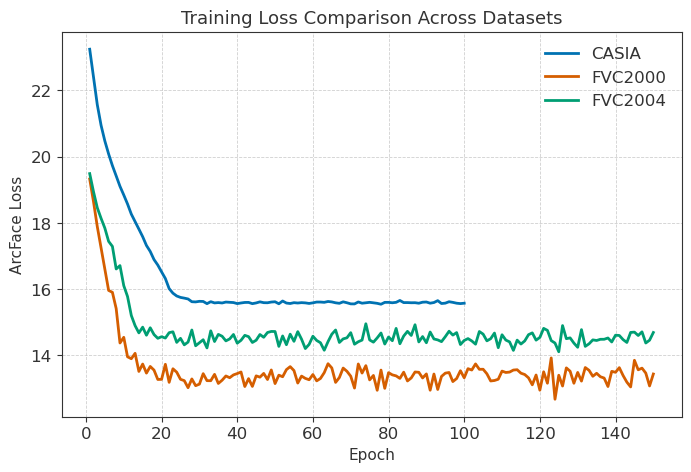

In [5]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import os

# ===== Color Palette =====
COLORS = {
    "primary": "#0072B2",      # Sky Blue
    "secondary": "#D55E00",    # Vermilion
    "tertiary": "#009E73",     # Bluish Green
    "bg": "#FFFFFF",           # Light Gray
    "text": "#333333"          # Charcoal
}

# Assign colors to runs explicitly (important for consistency)
RUN_COLORS = {
    "CASIA": COLORS["primary"],
    "FVC2000": COLORS["secondary"],
    "FVC2004": COLORS["tertiary"]
}

runs = {
    "CASIA": "casia_Quantized_20260322-143401",
    "FVC2000": "fvc2000_Quantized_20260322-220217",
    "FVC2004": "fvc2004_Quantized_20260322-230045"
}

tag = "Loss/ArcFace_Train"
base_dir = r"D:/Btech/Btech-4/Sem-8/BiometricTemplateGeneration/artifacts/plots/tensorboard"

# ===== Figure setup =====
plt.figure(figsize=(8,5), facecolor=COLORS["bg"])
ax = plt.gca()
ax.set_facecolor(COLORS["bg"])

for name, folder in runs.items():
    log_dir = os.path.join(base_dir, folder)
    
    ea = event_accumulator.EventAccumulator(
        log_dir,
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    
    scalars = ea.Scalars(tag)
    steps = [s.step for s in scalars]
    values = [s.value for s in scalars]
    
    plt.plot(
        steps,
        values,
        label=name,
        color=RUN_COLORS[name],
        linewidth=2
    )

# ===== Styling =====
plt.xlabel("Epoch", color=COLORS["text"], fontsize=11)
plt.ylabel("ArcFace Loss", color=COLORS["text"], fontsize=11)
plt.title("Training Loss Comparison Across Datasets", color=COLORS["text"], fontsize=13)

plt.legend(frameon=False)

# Grid styling
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

# Axis styling
ax.tick_params(colors=COLORS["text"])
for spine in ax.spines.values():
    spine.set_color(COLORS["text"])

# ===== Save =====
plt.savefig("arcface_loss_comparison.pdf", bbox_inches='tight')
plt.savefig("arcface_loss_comparison.png", dpi=300, bbox_inches='tight')

plt.show()